In [1]:
# Ignore  the warnings
import warnings
warnings.filterwarnings('always')
warnings.filterwarnings('ignore') 

In [2]:
# data visualisation and manipulation 
import numpy as np, pandas as pd, re, matplotlib.pyplot as plt, seaborn as sns, math, random

from matplotlib import style
from collections import Counter
 
#configure
# sets matplotlib to inline and displays graphs below the corressponding cell.
%matplotlib inline  
style.use('fivethirtyeight')
sns.set(style='whitegrid',color_codes=True)

#model selection
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score,precision_score, recall_score,confusion_matrix,roc_curve,roc_auc_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight

#preprocess.
from keras.preprocessing.image import ImageDataGenerator

#dl libraraies
import tensorflow as tf
from keras import backend as K
from keras.models import Sequential, load_model
from keras.layers import Dense, Dropout, Flatten, Activation, BatchNormalization
from keras.optimizers import Adam,SGD,Adagrad,Adadelta,RMSprop
from keras.utils import to_categorical
 
from tensorflow.keras import layers
import random as rn

# specifically for manipulating zipped images and getting numpy arrays of pixel values of images. 
import tqdm, os, glob, tempfile
from random import shuffle  
from PIL import Image

In [43]:
class CONFIG:
    HEIGHT = 256
    WIDTH = 256
    SEED = 42
    FOLDS = 5
    IMAGE_SIZES = [256, 256, 256, 256, 256] #same img size for each fold
    BATCH_SIZE = [16] * FOLDS
    EPOCHS = [20] * FOLDS
    WEIGHTS = [1/FOLDS] * FOLDS
    AUTO = tf.data.experimental.AUTOTUNE
    VERBOSE = 1

## Augmentation

In [68]:
ROTATION = 180.0 
SHEAR = 3.0
H_ZOOM = 8.0
W_ZOOM = 8.0
H_SHIFT = 8.0
W_SHIFT = 8.0

def create_3x3_matrix(list):
    """Reshape a list into a 3x3 matrix."""
    return tf.reshape(tf.concat([list], axis=0), [3, 3])

def compose_transformation_matrix(rotation, shear, height_zoom, width_zoom, height_shift, width_shift):
    """
    Create a composite transformation matrix from rotation, shear, zoom, and shift parameters.
    """
    rotation = math.pi * rotation / 180.0
    shear = math.pi * shear / 180.0

    c1 = tf.math.cos(rotation)
    s1 = tf.math.sin(rotation)
    one = tf.constant([1], dtype='float32')
    zero = tf.constant([0], dtype='float32')

    rotation_matrix = create_3x3_matrix([c1, s1, zero,
                                        -s1, c1, zero,
                                        zero, zero, one])
    c2 = tf.math.cos(shear)
    s2 = tf.math.sin(shear)

    shear_matrix = create_3x3_matrix([one, s2, zero,
                                     zero, c2, zero,
                                     zero, zero, one])
    zoom_matrix = create_3x3_matrix([one / height_zoom, zero, zero,
                                     zero, one / width_zoom, zero,
                                    zero, zero, one])
    shift_matrix = create_3x3_matrix([one, zero, height_shift,
                                     zero, one, width_shift,
                                     zero, zero, one])
    return tf.linalg.matmul(tf.linalg.matmul(rotation_matrix, shear_matrix), tf.linalg.matmul(zoom_matrix, shift_matrix))

def apply_random_transformations(image, dim=224): 
    """ Apply random transformations to an image. """
    xdim = dim % 2
    rot = ROTATION * tf.random.normal([1], dtype = 'float32')
    shr = SHEAR * tf.random.normal([1], dtype = 'float32')
    h_zoom = 1.0 + tf.random.normal([1], dtype = 'float32') / H_ZOOM
    w_zoom = 1.0 + tf.random.normal([1], dtype = 'float32') / W_ZOOM
    h_shift = H_SHIFT * tf.random.normal([1], dtype = 'float32')
    w_shift = W_SHIFT * tf.random.normal([1], dtype = 'float32') 

    # Get transformation matrix 
    m = compose_transformation_matrix(rot, shr, h_zoom, w_zoom, h_shift, w_shift)

    # list destination pixel indices 
    x = tf.repeat(tf.range(dim // 2, -dim // 2, -1), dim)
    y = tf.tile(tf.range(-dim // 2, dim // 2), [dim])
    z = tf.ones([dim * dim], dtype = 'int32')
    idx = tf.stack([x, y, z])

    # Rotate destination pixels onto origin pixels
    idx2 = tf.linalg.matmul(m, tf.cast(idx, dtype='float32'))
    idx2 = tf.cast(idx2, dtype = 'int32')
    idx2 = tf.clip_by_value(idx2, -dim //2 + xdim + 1, dim // 2)

    # Find origin pixel values
    idx3 = tf.stack([dim // 2 - idx2[0,], dim // 2 - 1 + idx2[1,]])
    d = tf.gather_nd(image, tf.transpose(idx3))

    return tf.reshape(d, [dim, dim, 3]) 

In [62]:
def read_labeled_tfrecord(example):
    """ parse a TFRecord example into an image and label. """
    tfrec_format = {
        'image': tf.io.FixedLenFeature([], tf.string),
        'label': tf.io.FixedLenFeature([], tf.float32)
    }
    example = tf.io.parse_single_example(example, tfrec_format)
    image = tf.io.decode_jpeg(example['image'], channels = 3)

    # Normalize the image to [0, 1] range 
    image = tf.image.convert_image_dtype(image, tf.float32)

    # Get the label 
    label = example['label']

    return image, label

def prepare_image(img, augment = True, dim = 224):
    """ Prepare an image for training or evaluation, with optional augmentation. """
    if augment:
        img = apply_random_transformations(img, dim = dim)
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_saturation(img, 0.8, 1.2)
        img = tf.image.random_contrast(img, 0.9, 1.1)
        img = tf.image.random_brightness(img, 0.1)

    # Resize the image if necessary
    img = tf.image.resize(img, [dim, dim])

    return img

def count_data_items(file_paths):
    """ Count the total number of items in a list of TFRecord files. """
    total_items = 0
    for file_path in file_paths:
        for record in tf.data.TFRecordDataset(file_path):
            total_items +=1

    return total_items


In [63]:
def get_dataset(files, augment = False, shuffle = False, repeat = False, dim = 224):
    """ Create a TensorFlow dataset from TFRecord files.
    Parameters:
    -files: List of TFRecord files. 
    -augment: Boolean, whether to apply data augmentation.
    -shuffle: Boolean, whether to shuffle the dataset.
    -repeat: Boolean, whether to repeat the dataset.
    -labeled: Boolean, whether the TFRecords contain labels.
    Returns:
    - A TensorFlow dataset ready for training or evaluation. 
    """
    ds = tf.data.TFRecordDataset(files, num_parallel_reads = tf.data.experimental.AUTOTUNE)
    ds = ds.cache()

    if repeat: 
        ds = ds.repeat() 
    if shuffle: 
        ds = ds.shuffle(1024 * 8) 
        opt = tf.data.Options() 
        opt.experimental_deterministic = False
        ds = ds.with_options(opt)
    ds = ds.map(read_labeled_tfrecord, num_parallel_calls = tf.data.experimental.AUTOTUNE)
    ds = ds.map(lambda img, label: (prepare_image(img, augment = augment, dim = dim), label), num_parallel_calls = tf.data.experimental.AUTOTUNE)
    ds = ds.prefetch(tf.data.experimental.AUTOTUNE)
    
    # Convert datasets to arrays for compatibility with Stratified Kfold
    images = []
    labels = []
    for features, label in ds:
        images.append(features.numpy())
        labels.append(label.numpy())
    return np.array(images), np.array(labels)


In [7]:
METRICS = [
    tf.keras.metrics.BinaryCrossentropy(name = 'Cross Entropy'),
    tf.keras.metrics.F1Score(name = 'f1_score'),
    tf.keras.metrics.TruePositives(name = 'TP'),
    tf.keras.metrics.FalsePositives(name = 'FP'),
    tf.keras.metrics.TrueNegatives(name = 'TN'),
    tf.keras.metrics.FalseNegatives(name = 'FN'),
    tf.keras.metrics.BinaryAccuracy(name = 'accuracy'),
    tf.keras.metrics.BinaryAccuracy(name='val_acc'),
    tf.keras.metrics.Precision(name = 'precision'),
    tf.keras.metrics.Recall(name = 'recall'),
    tf.keras.metrics.AUC(name = 'auc'),
    tf.keras.metrics.AUC(name = 'prc', curve = 'PR'), #precision recall curve
]

In [69]:
def build_model(dim = 224):
    model = Sequential([
        layers.Input(shape = (CONFIG.HEIGHT, CONFIG.WIDTH, 3)),

        layers.Conv2D(16, kernel_size = 3, activation = 'relu', name = 'conv_1'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size = 2, padding = 'valid', name = 'maxpool_1'),
        
        layers.Conv2D(32, kernel_size = 3, activation = 'relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size = 2, padding = 'valid'),

        layers.Conv2D(64, kernel_size = 3, activation = 'relu', name = 'conv_2'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size = 2, padding = 'valid', name = 'maxpool_2'),

        layers.Conv2D(128, kernel_size = 3, activation = 'relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size = 2, padding = 'valid'),

        layers.Conv2D(256, kernel_size = 3, activation = 'relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size = 2, padding = 'valid'),

        layers.Conv2D(256, kernel_size = 3, activation = 'relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size = 2, padding = 'valid'),
        
        layers.GlobalAveragePooling2D(),
        layers.Flatten(),
        layers.BatchNormalization(),
        
        layers.Dense(256, activation = 'relu', name = 'fully_connected_1'),
        layers.Dropout(0.4),
        layers.Dense(1, activation = 'sigmoid')
    ])

    optimization = tf.keras.optimizers.Adam(learning_rate = 0.001)
    loss = tf.keras.losses.BinaryCrossentropy(label_smoothing = 0.05)
    model.compile(optimizer = optimization, loss = loss, metrics = METRICS)

    return model 

In [9]:
def get_lr_callback(batch_size = 8):
    """ Creat a learning rate callback with a custom learning rate schedule. """
    lr_start = 0.000005
    lr_max = 0.00000125 * batch_size
    lr_min = 0.000001
    lr_ramp_epochs = 5
    lr_sustain_epochs = 0
    lr_decay = 0.8

    def lrfn(epoch):
        if epoch < lr_ramp_epochs:
            lr = (lr_max - lr_start) / lr_ramp_epochs * epoch + lr_start 
        elif epoch < lr_ramp_epochs + lr_sustain_epochs:
            lr = lr_max
        else:
            lr = (lr_max - lr_min) * lr_decay ** (epoch - lr_ramp_epochs - lr_sustain_epochs) + lr_min
        return lr
    lr_callback = tf.keras.callbacks.LearningRateScheduler(lrfn, verbose = 1)
    return lr_callback 



___________________________FOLD 1__________________________

Training ...

Epoch 1: LearningRateScheduler setting learning rate to 5e-06.
Epoch 1/20
107/107 [==============================] - 282s 3s/step - loss: 0.7363 - Cross Entropy: 0.7176 - f1_score: 0.3182 - TP: 131.0000 - FP: 561.0000 - TN: 879.0000 - FN: 205.0000 - accuracy: 0.5687 - val_acc: 0.5687 - precision: 0.1893 - recall: 0.3899 - auc: 0.5178 - prc: 0.1984 - val_loss: 0.7047 - val_Cross Entropy: 0.7053 - val_f1_score: 0.3055 - val_TP: 65.0000 - val_FP: 290.0000 - val_TN: 51.0000 - val_FN: 10.0000 - val_accuracy: 0.2788 - val_val_acc: 0.2788 - val_precision: 0.1831 - val_recall: 0.8667 - val_auc: 0.4786 - val_prc: 0.1663 - lr: 5.0000e-06

Epoch 2: LearningRateScheduler setting learning rate to 8.000000000000001e-06.
Epoch 2/20
107/107 [==============================] - 269s 3s/step - loss: 0.5767 - Cross Entropy: 0.5597 - f1_score: 0.3154 - TP: 83.0000 - FP: 223.0000 - TN: 1162.0000 - FN: 236.0000 - accuracy: 0.7306 - va

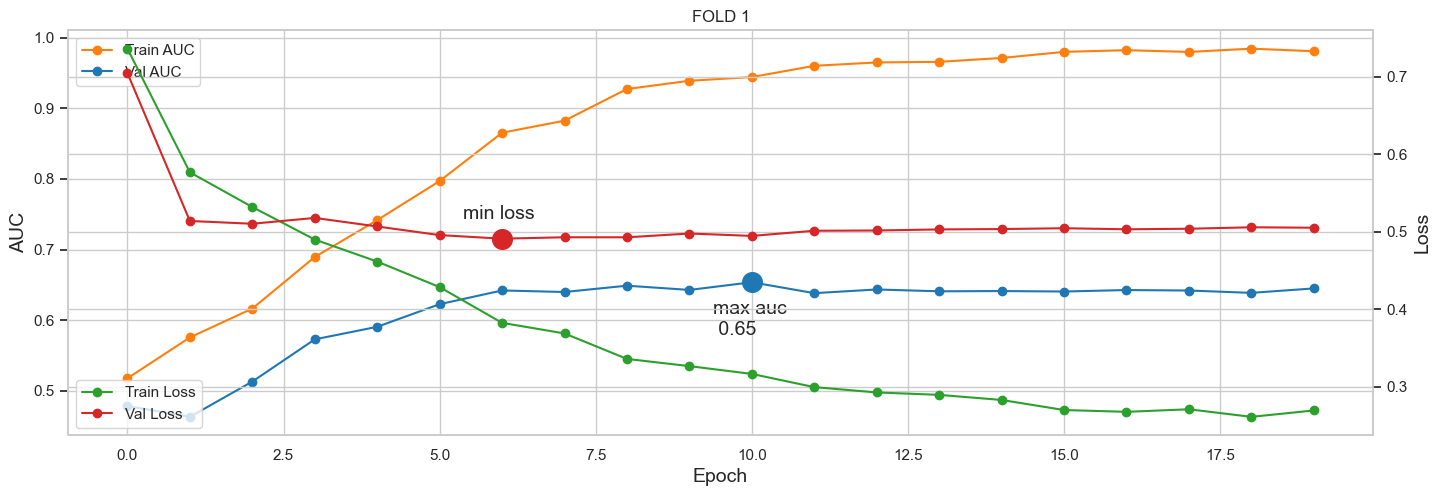


___________________________FOLD 2__________________________

Training ...

Epoch 1: LearningRateScheduler setting learning rate to 5e-06.
Epoch 1/20
107/107 [==============================] - 282s 3s/step - loss: 0.8356 - Cross Entropy: 0.7660 - f1_score: 0.3145 - TP: 191.0000 - FP: 778.0000 - TN: 953.0000 - FN: 206.0000 - accuracy: 0.5376 - val_acc: 0.5376 - precision: 0.1971 - recall: 0.4811 - auc: 0.5255 - prc: 0.2051 - val_loss: 0.7448 - val_Cross Entropy: 0.7474 - val_f1_score: 0.3020 - val_TP: 74.0000 - val_FP: 342.0000 - val_TN: 0.0000e+00 - val_FN: 0.0000e+00 - val_accuracy: 0.1779 - val_val_acc: 0.1779 - val_precision: 0.1779 - val_recall: 1.0000 - val_auc: 0.4945 - val_prc: 0.2046 - lr: 5.0000e-06

Epoch 2: LearningRateScheduler setting learning rate to 8.000000000000001e-06.
Epoch 2/20
107/107 [==============================] - 265s 2s/step - loss: 0.6111 - Cross Entropy: 0.5984 - f1_score: 0.3145 - TP: 102.0000 - FP: 321.0000 - TN: 1065.0000 - FN: 216.0000 - accuracy: 0.68

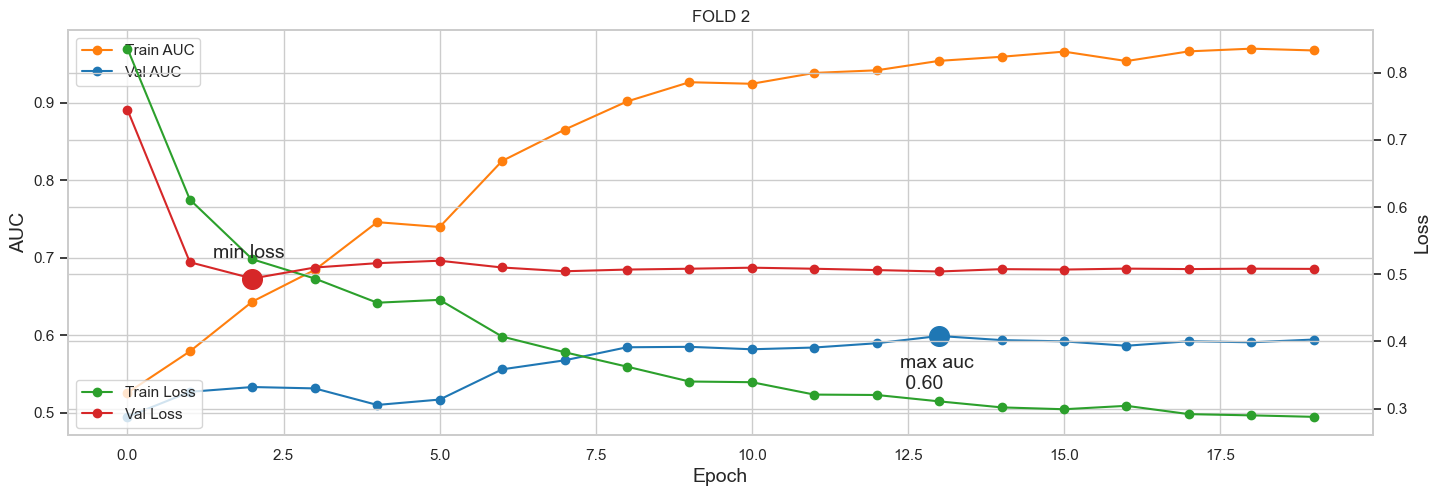


___________________________FOLD 3__________________________

Training ...

Epoch 1: LearningRateScheduler setting learning rate to 5e-06.
Epoch 1/20
107/107 [==============================] - 185s 2s/step - loss: 0.9140 - Cross Entropy: 0.8330 - f1_score: 0.3138 - TP: 196.0000 - FP: 877.0000 - TN: 855.0000 - FN: 200.0000 - accuracy: 0.4939 - val_acc: 0.4939 - precision: 0.1827 - recall: 0.4949 - auc: 0.5076 - prc: 0.1868 - val_loss: 0.9189 - val_Cross Entropy: 0.9284 - val_f1_score: 0.3124 - val_TP: 77.0000 - val_FP: 339.0000 - val_TN: 0.0000e+00 - val_FN: 0.0000e+00 - val_accuracy: 0.1851 - val_val_acc: 0.1851 - val_precision: 0.1851 - val_recall: 1.0000 - val_auc: 0.4743 - val_prc: 0.1721 - lr: 5.0000e-06

Epoch 2: LearningRateScheduler setting learning rate to 8.000000000000001e-06.
Epoch 2/20
107/107 [==============================] - 179s 2s/step - loss: 0.6604 - Cross Entropy: 0.6505 - f1_score: 0.3145 - TP: 110.0000 - FP: 405.0000 - TN: 981.0000 - FN: 208.0000 - accuracy: 0.640

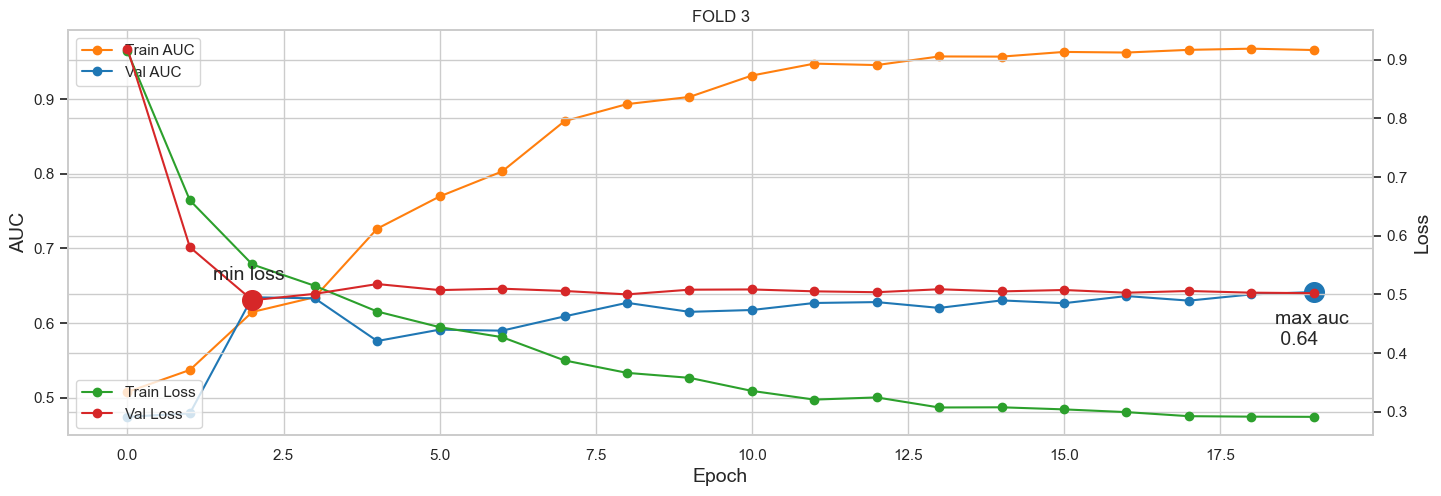


___________________________FOLD 4__________________________

Training ...

Epoch 1: LearningRateScheduler setting learning rate to 5e-06.
Epoch 1/20
107/107 [==============================] - 206s 2s/step - loss: 0.6381 - Cross Entropy: 0.5957 - f1_score: 0.3158 - TP: 87.0000 - FP: 312.0000 - TN: 1417.0000 - FN: 312.0000 - accuracy: 0.7068 - val_acc: 0.7068 - precision: 0.2180 - recall: 0.2180 - auc: 0.5378 - prc: 0.2061 - val_loss: 0.5495 - val_Cross Entropy: 0.5390 - val_f1_score: 0.3192 - val_TP: 0.0000e+00 - val_FP: 0.0000e+00 - val_TN: 337.0000 - val_FN: 79.0000 - val_accuracy: 0.8101 - val_val_acc: 0.8101 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_auc: 0.5680 - val_prc: 0.2334 - lr: 5.0000e-06

Epoch 2: LearningRateScheduler setting learning rate to 8.000000000000001e-06.
Epoch 2/20
107/107 [==============================] - 202s 2s/step - loss: 0.5509 - Cross Entropy: 0.5305 - f1_score: 0.3120 - TP: 53.0000 - FP: 153.0000 - TN: 1236.0000 - FN: 262.0000 - accurac

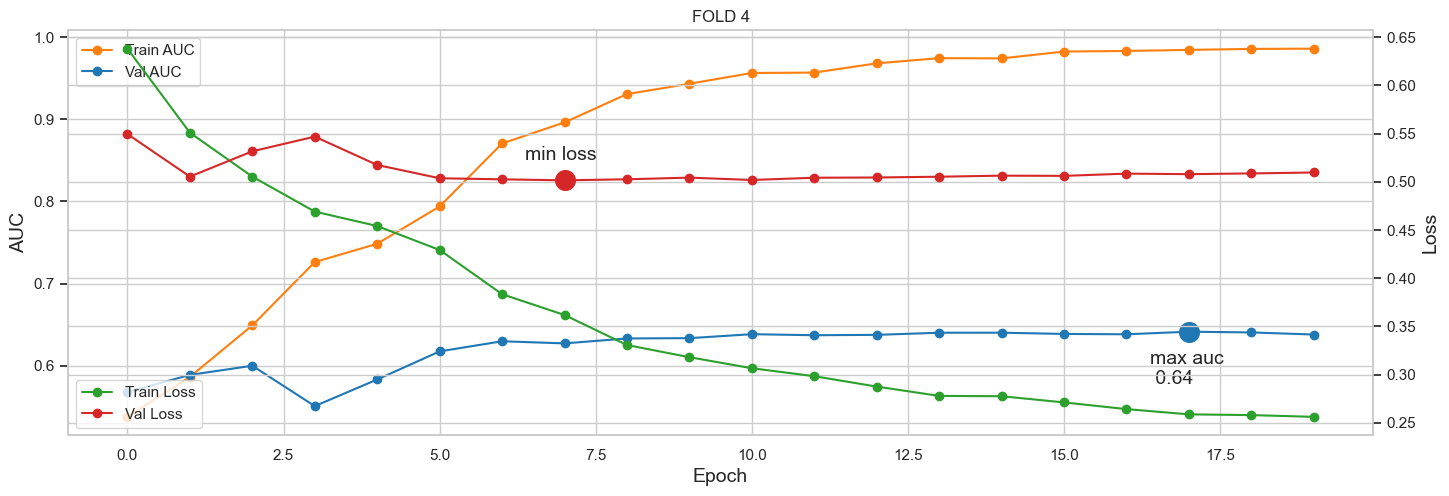


___________________________FOLD 5__________________________

Training ...

Epoch 1: LearningRateScheduler setting learning rate to 5e-06.
Epoch 1/20
107/107 [==============================] - 271s 3s/step - loss: 0.7250 - Cross Entropy: 0.6722 - f1_score: 0.3171 - TP: 105.0000 - FP: 498.0000 - TN: 1229.0000 - FN: 296.0000 - accuracy: 0.6269 - val_acc: 0.6269 - precision: 0.1741 - recall: 0.2618 - auc: 0.5059 - prc: 0.1841 - val_loss: 0.7745 - val_Cross Entropy: 0.7784 - val_f1_score: 0.3158 - val_TP: 78.0000 - val_FP: 338.0000 - val_TN: 0.0000e+00 - val_FN: 0.0000e+00 - val_accuracy: 0.1875 - val_val_acc: 0.1875 - val_precision: 0.1875 - val_recall: 1.0000 - val_auc: 0.5452 - val_prc: 0.2232 - lr: 5.0000e-06

Epoch 2: LearningRateScheduler setting learning rate to 8.000000000000001e-06.
Epoch 2/20
107/107 [==============================] - 261s 2s/step - loss: 0.5813 - Cross Entropy: 0.5625 - f1_score: 0.3137 - TP: 64.0000 - FP: 206.0000 - TN: 1181.0000 - FN: 253.0000 - accuracy: 0.73

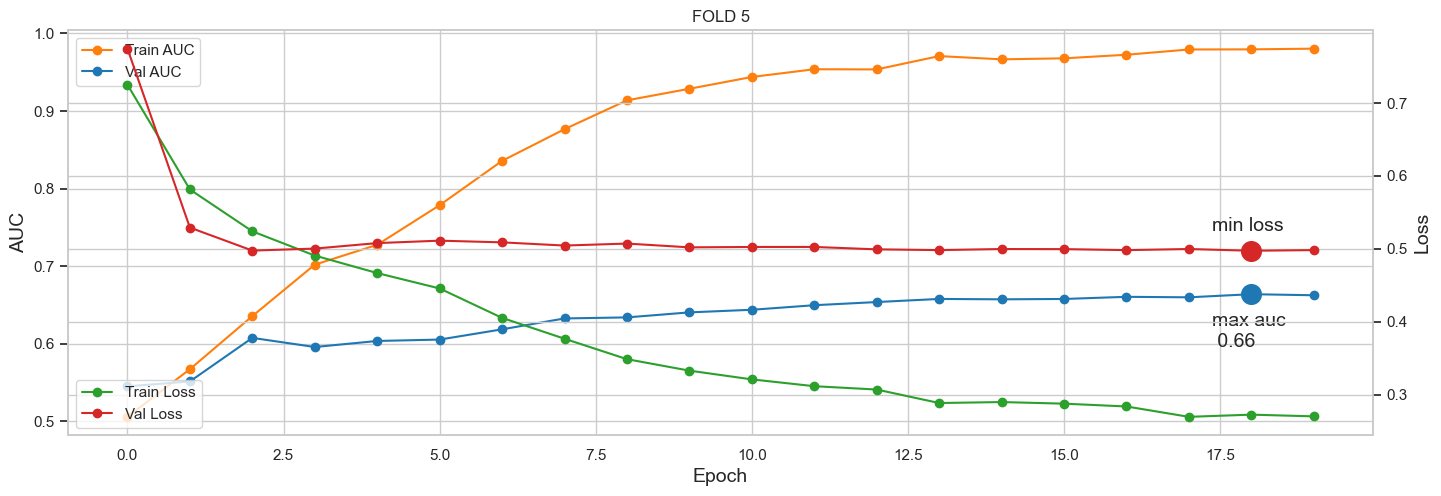

In [70]:
# 32-16-8-4
DISPLAY_PLOT = True

# Define paths
tfrec_train_files = tf.io.gfile.glob('../../dataset/tf_records/train00.tfrec')
tfrec_test_files = tf.io.gfile.glob('../../dataset/tf_records/test00.tfrec')

#Load datasets 
train_data, train_labels = get_dataset(tfrec_train_files, augment = True, shuffle = True, repeat = False, dim = 256)
test_data, test_labels = get_dataset(tfrec_test_files, augment = True, shuffle = False, repeat = False, dim = 256)

# Predictions array for test set
test_preds = np.zeros((count_data_items(tfrec_test_files), 1))

# Stratified K-Fold Cross-Validation
skf = StratifiedKFold(n_splits = CONFIG.FOLDS, shuffle = True, random_state = CONFIG.SEED)
oof_pred, oof_tar, oof_val, oof_folds = [], [], [],[] 

for fold, (train_idx, val_idx) in enumerate(skf.split(train_data, train_labels)):
    
    print(f'\n___________________________FOLD {fold + 1}__________________________\n')

    # Create train and validation datasets
    train_subset_data, train_subset_labels = train_data[train_idx], train_labels[train_idx]
    val_subset_data, val_subset_labels = train_data[val_idx], train_labels[val_idx]

    train_dataset = tf.data.Dataset.from_tensor_slices((train_subset_data, train_subset_labels))
    val_dataset = tf.data.Dataset.from_tensor_slices((val_subset_data, val_subset_labels))

    # Batch and shuffle datasets 
    #.shuffle(len(train_subset_labels))
    train_dataset = train_dataset.batch(CONFIG.BATCH_SIZE[fold]).repeat() 
    val_dataset = val_dataset.batch(CONFIG.BATCH_SIZE[fold])

    steps_per_epoch = len(train_subset_labels) // CONFIG.BATCH_SIZE[fold]
    validation_steps = len(val_subset_labels) // CONFIG.BATCH_SIZE[fold]

    # Class Weight
    
    # Build and compile model 
    tf.keras.backend.clear_session()
    model = build_model(dim = 256)

    # Save best model checkpoint callback 
    checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(filepath=f'fold-{fold}.h5', 
                                                             monitor = 'val_loss', verbose = 0,
                                                             save_best_only = True, save_weights_only = True, mode = 'min',
                                                             save_freq = 'epoch')

    # Train Model
    print('Training ...')
    
    history = model.fit(train_dataset, epochs = CONFIG.EPOCHS[fold],
                        steps_per_epoch = steps_per_epoch, validation_data = val_dataset,
                        validation_steps = validation_steps, callbacks = [ checkpoint_callback,get_lr_callback(CONFIG.BATCH_SIZE[fold])],
                        verbose = CONFIG.VERBOSE)
    
    # Load best model weights
    print('Loading best model...')
    model.load_weights(f'fold-{fold}.h5')

    # Predic OOF 
    print('Predicting OOF with TTA...')
    val_preds = model.predict(val_dataset, verbose = 0)
    oof_pred.append(np.mean(val_preds, axis = 1))
    oof_tar.append(np.array([label.numpy() for _, label in val_dataset.unbatch()]))
    oof_folds.append(np.ones_like(oof_tar[-1], dtype = 'int8') * fold)

    # Predict on test set 
    print('Predicting Test with TTA...')
    test_preds += model.predict(test_data, verbose = 0 ) / CONFIG.FOLDS

    # cALCULATE AUC
    fold_auc = roc_auc_score(oof_tar[-1], oof_pred[-1])
    oof_val.append(np.max(history.history['val_auc']))
    print(f'#### FOLD {fold + 1} OOF AUC without TTA = {oof_val[-1]:.3f}, with TTA = {fold_auc:.3f}')

    # Plot training history
    if DISPLAY_PLOT:
        plt.figure(figsize = (15, 5))
        plt.plot(np.arange(CONFIG.EPOCHS[fold]), history.history['auc'], '-o', label = 'Train AUC', color = '#ff7f0e')
        plt.plot(np.arange(CONFIG.EPOCHS[fold]), history.history['val_auc'], '-o', label = 'Val AUC', color = '#1f77b4')
        x = np.argmax(history.history['val_auc'])
        y = np.max(history.history['val_auc'])
        xdist = plt.xlim()[1] - plt.xlim()[0]
        ydist = plt.ylim()[1] - plt.ylim()[0]
        plt.scatter(x, y, s = 200, color = '#1f77b4')
        plt.text(x - 0.03 * xdist, y - 0.13 * ydist, f'max auc \n {y:.2f}', size = 14)
        plt.ylabel('AUC', size = 14)
        plt.xlabel('Epoch', size = 14)
        plt.legend(loc = 2)

        plt2 = plt.gca().twinx()
        plt2.plot(np.arange(CONFIG.EPOCHS[fold]), history.history['loss'], '-o', label = 'Train Loss', color = '#2ca02c')
        plt.plot(np.arange(CONFIG.EPOCHS[fold]), history.history['val_loss'], '-o', label = 'Val Loss', color = '#d62728')
        x = np.argmin(history.history['val_loss']) 
        y = np.min(history.history['val_loss']) 
        ydist = plt.ylim()[1] - plt.ylim()[0] 
        plt.scatter(x, y, s = 200, color = '#d62728') 
        plt.text(x - 0.03 * xdist, y + 0.05 * ydist, 'min loss', size = 14) 
        plt.ylabel('Loss', size = 14) 
        plt.title(f'FOLD {fold + 1}') 
        plt.legend(loc = 3) 
        plt.show() 


___________________________FOLD 1__________________________

Training ...

Epoch 1: LearningRateScheduler setting learning rate to 5e-06.
Epoch 1/20
107/107 [==============================] - 96s 873ms/step - loss: 0.7569 - Cross Entropy: 0.5569 - f1_score: 0.3170 - TP: 299.0000 - FP: 715.0000 - TN: 1720.0000 - FN: 266.0000 - accuracy: 0.6730 - val_acc: 0.6730 - precision: 0.2949 - recall: 0.5292 - auc: 0.7044 - prc: 0.3238 - val_loss: 0.6936 - val_Cross Entropy: 0.6936 - val_f1_score: 0.3192 - val_TP: 46.0000 - val_FP: 217.0000 - val_TN: 120.0000 - val_FN: 33.0000 - val_accuracy: 0.3990 - val_val_acc: 0.3990 - val_precision: 0.1749 - val_recall: 0.5823 - val_auc: 0.5086 - val_prc: 0.2014 - lr: 5.0000e-06

Epoch 2: LearningRateScheduler setting learning rate to 8.000000000000001e-06.
Epoch 2/20
107/107 [==============================] - 96s 904ms/step - loss: 0.6056 - Cross Entropy: 0.5942 - f1_score: 0.3154 - TP: 56.0000 - FP: 243.0000 - TN: 1142.0000 - FN: 263.0000 - accuracy: 0.703

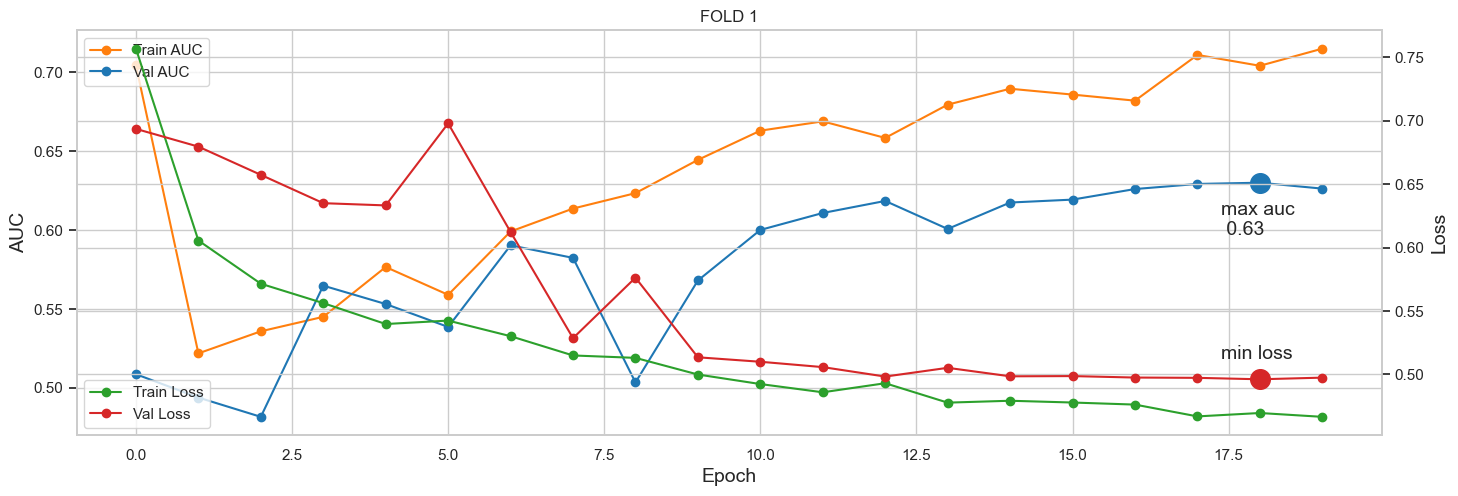


___________________________FOLD 2__________________________

Training ...

Epoch 1: LearningRateScheduler setting learning rate to 5e-06.
Epoch 1/20
107/107 [==============================] - 98s 900ms/step - loss: 0.6288 - Cross Entropy: 0.5894 - f1_score: 0.3165 - TP: 53.0000 - FP: 267.0000 - TN: 1461.0000 - FN: 347.0000 - accuracy: 0.7115 - val_acc: 0.7115 - precision: 0.1656 - recall: 0.1325 - auc: 0.5106 - prc: 0.1940 - val_loss: 0.6785 - val_Cross Entropy: 0.6777 - val_f1_score: 0.3089 - val_TP: 0.0000e+00 - val_FP: 0.0000e+00 - val_TN: 340.0000 - val_FN: 76.0000 - val_accuracy: 0.8173 - val_val_acc: 0.8173 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_auc: 0.4671 - val_prc: 0.1677 - lr: 5.0000e-06

Epoch 2: LearningRateScheduler setting learning rate to 8.000000000000001e-06.
Epoch 2/20
107/107 [==============================] - 95s 888ms/step - loss: 0.5669 - Cross Entropy: 0.5492 - f1_score: 0.3154 - TP: 32.0000 - FP: 122.0000 - TN: 1263.0000 - FN: 287.0000 - acc

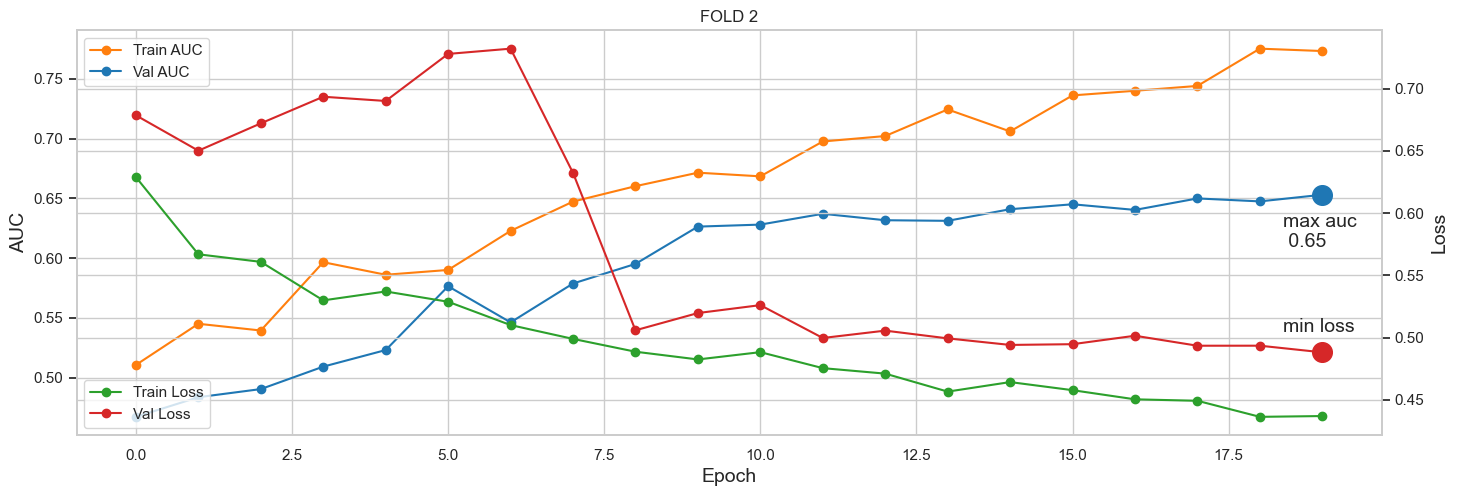


___________________________FOLD 3__________________________

Training ...

Epoch 1: LearningRateScheduler setting learning rate to 5e-06.
Epoch 1/20
107/107 [==============================] - 157s 1s/step - loss: 0.6344 - Cross Entropy: 0.5938 - f1_score: 0.3138 - TP: 92.0000 - FP: 339.0000 - TN: 1393.0000 - FN: 304.0000 - accuracy: 0.6978 - val_acc: 0.6978 - precision: 0.2135 - recall: 0.2323 - auc: 0.5432 - prc: 0.2066 - val_loss: 0.6937 - val_Cross Entropy: 0.6937 - val_f1_score: 0.3192 - val_TP: 58.0000 - val_FP: 195.0000 - val_TN: 142.0000 - val_FN: 21.0000 - val_accuracy: 0.4808 - val_val_acc: 0.4808 - val_precision: 0.2292 - val_recall: 0.7342 - val_auc: 0.4962 - val_prc: 0.1874 - lr: 5.0000e-06

Epoch 2: LearningRateScheduler setting learning rate to 8.000000000000001e-06.
Epoch 2/20
107/107 [==============================] - 150s 1s/step - loss: 0.5689 - Cross Entropy: 0.5529 - f1_score: 0.3154 - TP: 49.0000 - FP: 166.0000 - TN: 1219.0000 - FN: 270.0000 - accuracy: 0.7441 - v

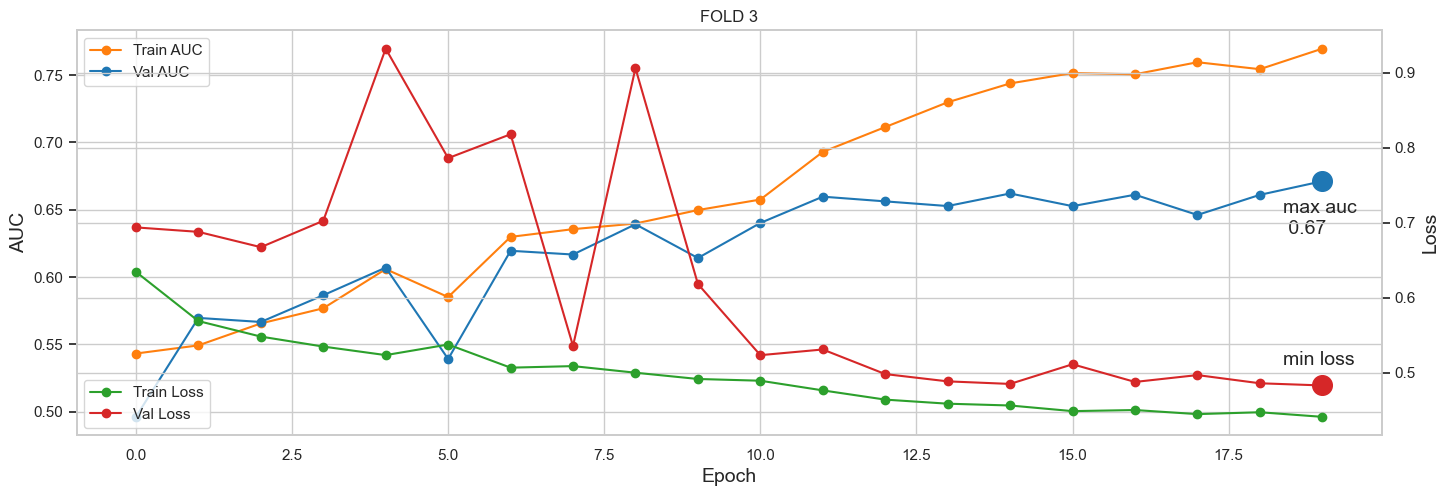


___________________________FOLD 4__________________________

Training ...

Epoch 1: LearningRateScheduler setting learning rate to 5e-06.
Epoch 1/20
107/107 [==============================] - 135s 1s/step - loss: 0.6026 - Cross Entropy: 0.5622 - f1_score: 0.3165 - TP: 55.0000 - FP: 191.0000 - TN: 1537.0000 - FN: 345.0000 - accuracy: 0.7481 - val_acc: 0.7481 - precision: 0.2236 - recall: 0.1375 - auc: 0.5329 - prc: 0.2130 - val_loss: 0.6799 - val_Cross Entropy: 0.6792 - val_f1_score: 0.3226 - val_TP: 0.0000e+00 - val_FP: 0.0000e+00 - val_TN: 336.0000 - val_FN: 80.0000 - val_accuracy: 0.8077 - val_val_acc: 0.8077 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_auc: 0.5075 - val_prc: 0.2076 - lr: 5.0000e-06

Epoch 2: LearningRateScheduler setting learning rate to 8.000000000000001e-06.
Epoch 2/20
107/107 [==============================] - 133s 1s/step - loss: 0.5562 - Cross Entropy: 0.5378 - f1_score: 0.3145 - TP: 34.0000 - FP: 106.0000 - TN: 1280.0000 - FN: 284.0000 - accurac

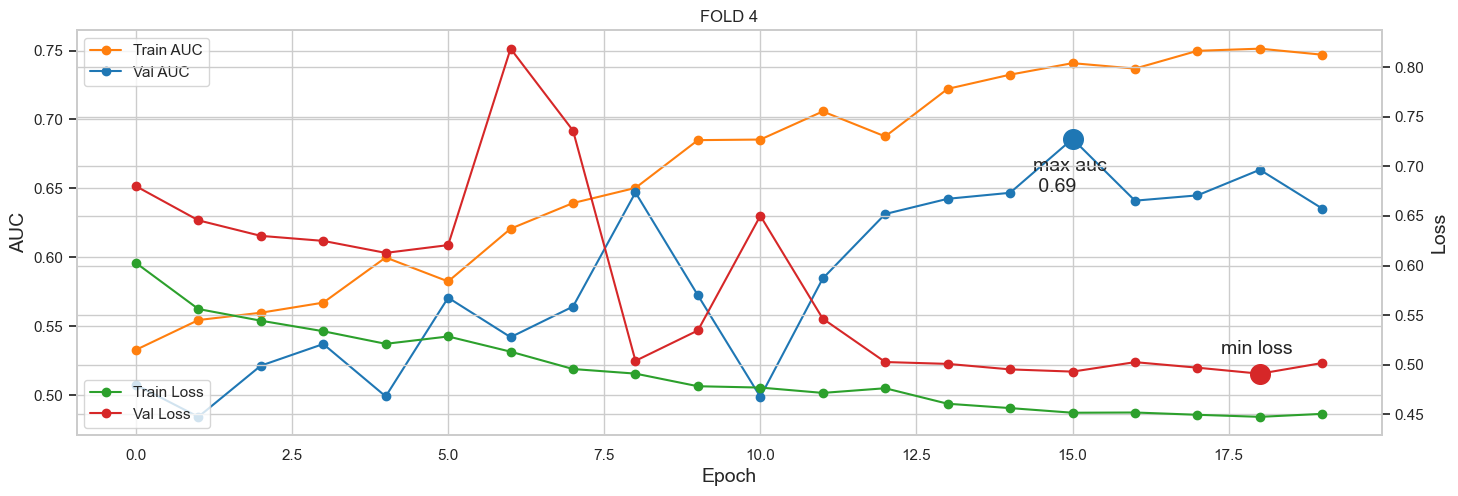


___________________________FOLD 5__________________________

Training ...

Epoch 1: LearningRateScheduler setting learning rate to 5e-06.
Epoch 1/20
107/107 [==============================] - 148s 1s/step - loss: 0.6003 - Cross Entropy: 0.5657 - f1_score: 0.3185 - TP: 45.0000 - FP: 181.0000 - TN: 1544.0000 - FN: 358.0000 - accuracy: 0.7467 - val_acc: 0.7467 - precision: 0.1991 - recall: 0.1117 - auc: 0.5095 - prc: 0.1906 - val_loss: 0.6846 - val_Cross Entropy: 0.6841 - val_f1_score: 0.3089 - val_TP: 2.0000 - val_FP: 6.0000 - val_TN: 334.0000 - val_FN: 74.0000 - val_accuracy: 0.8077 - val_val_acc: 0.8077 - val_precision: 0.2500 - val_recall: 0.0263 - val_auc: 0.4342 - val_prc: 0.1584 - lr: 5.0000e-06

Epoch 2: LearningRateScheduler setting learning rate to 8.000000000000001e-06.
Epoch 2/20
107/107 [==============================] - 140s 1s/step - loss: 0.5610 - Cross Entropy: 0.5425 - f1_score: 0.3154 - TP: 28.0000 - FP: 103.0000 - TN: 1282.0000 - FN: 291.0000 - accuracy: 0.7688 - val_

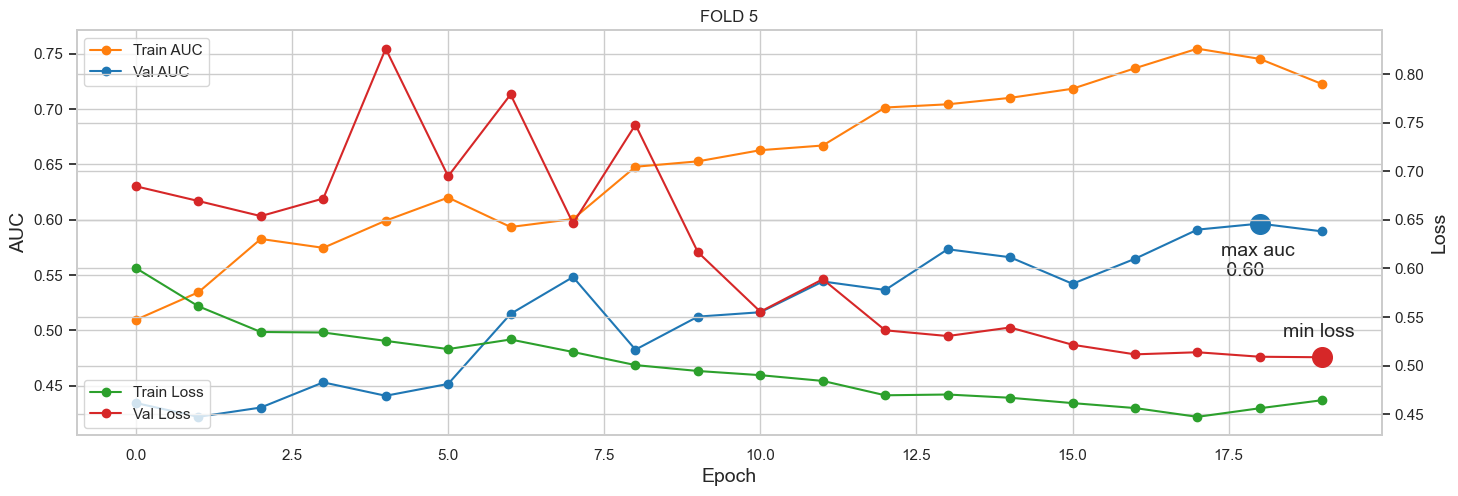

In [52]:
# 32-16-8-4
DISPLAY_PLOT = True

# Define paths
tfrec_train_files = tf.io.gfile.glob('../../dataset/tf_records/train00.tfrec')
tfrec_test_files = tf.io.gfile.glob('../../dataset/tf_records/test00.tfrec')

#Load datasets 
train_data, train_labels = get_dataset(tfrec_train_files, augment = True, shuffle = True, repeat = False, dim = 256)
test_data, test_labels = get_dataset(tfrec_test_files, augment = True, shuffle = False, repeat = False, dim = 256)

# Predictions array for test set
test_preds = np.zeros((count_data_items(tfrec_test_files), 1))

# Stratified K-Fold Cross-Validation
skf = StratifiedKFold(n_splits = CONFIG.FOLDS, shuffle = True, random_state = CONFIG.SEED)
oof_pred, oof_tar, oof_val, oof_folds = [], [], [],[] 

for fold, (train_idx, val_idx) in enumerate(skf.split(train_data, train_labels)):
    
    print(f'\n___________________________FOLD {fold + 1}__________________________\n')

    # Create train and validation datasets 
    train_subset_data, train_subset_labels = train_data[train_idx], train_labels[train_idx]
    val_subset_data, val_subset_labels = train_data[val_idx], train_labels[val_idx]

    train_dataset = tf.data.Dataset.from_tensor_slices((train_subset_data, train_subset_labels))
    val_dataset = tf.data.Dataset.from_tensor_slices((val_subset_data, val_subset_labels))

    # Batch and shuffle datasets 
    #.shuffle(len(train_subset_labels))
    train_dataset = train_dataset.batch(CONFIG.BATCH_SIZE[fold]).repeat() 
    val_dataset = val_dataset.batch(CONFIG.BATCH_SIZE[fold])

    steps_per_epoch = len(train_subset_labels) // CONFIG.BATCH_SIZE[fold]
    validation_steps = len(val_subset_labels) // CONFIG.BATCH_SIZE[fold]

    # Class Weight
    
    # Build and compile model 
    tf.keras.backend.clear_session()
    model = build_model(dim = 256)

    # Save best model checkpoint callback 
    checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(filepath=f'fold-{fold}.h5', 
                                                             monitor = 'val_loss', verbose = 0,
                                                             save_best_only = True, save_weights_only = True, mode = 'min',
                                                             save_freq = 'epoch')

    # Train Model
    print('Training ...')
    
    history = model.fit(train_dataset, epochs = CONFIG.EPOCHS[fold],
                        steps_per_epoch = steps_per_epoch, validation_data = val_dataset,
                        validation_steps = validation_steps, callbacks = [ checkpoint_callback,get_lr_callback(CONFIG.BATCH_SIZE[fold])],
                        verbose = CONFIG.VERBOSE)
    
    # Load best model weights
    print('Loading best model...')
    model.load_weights(f'fold-{fold}.h5')

    # Predic OOF 
    print('Predicting OOF with TTA...')
    val_preds = model.predict(val_dataset, verbose = 0)
    oof_pred.append(np.mean(val_preds, axis = 1))
    oof_tar.append(np.array([label.numpy() for _, label in val_dataset.unbatch()]))
    oof_folds.append(np.ones_like(oof_tar[-1], dtype = 'int8') * fold)

    # Predict on test set 
    print('Predicting Test with TTA...')
    test_preds += model.predict(test_data, verbose = 0 ) / CONFIG.FOLDS

    # cALCULATE AUC
    fold_auc = roc_auc_score(oof_tar[-1], oof_pred[-1])
    oof_val.append(np.max(history.history['val_auc']))
    print(f'#### FOLD {fold + 1} OOF AUC without TTA = {oof_val[-1]:.3f}, with TTA = {fold_auc:.3f}')

    # Plot training history
    if DISPLAY_PLOT:
        plt.figure(figsize = (15, 5))
        plt.plot(np.arange(CONFIG.EPOCHS[fold]), history.history['auc'], '-o', label = 'Train AUC', color = '#ff7f0e')
        plt.plot(np.arange(CONFIG.EPOCHS[fold]), history.history['val_auc'], '-o', label = 'Val AUC', color = '#1f77b4')
        x = np.argmax(history.history['val_auc'])
        y = np.max(history.history['val_auc'])
        xdist = plt.xlim()[1] - plt.xlim()[0]
        ydist = plt.ylim()[1] - plt.ylim()[0]
        plt.scatter(x, y, s = 200, color = '#1f77b4')
        plt.text(x - 0.03 * xdist, y - 0.13 * ydist, f'max auc \n {y:.2f}', size = 14)
        plt.ylabel('AUC', size = 14)
        plt.xlabel('Epoch', size = 14)
        plt.legend(loc = 2)

        plt2 = plt.gca().twinx()
        plt2.plot(np.arange(CONFIG.EPOCHS[fold]), history.history['loss'], '-o', label = 'Train Loss', color = '#2ca02c')
        plt.plot(np.arange(CONFIG.EPOCHS[fold]), history.history['val_loss'], '-o', label = 'Val Loss', color = '#d62728')
        x = np.argmin(history.history['val_loss'])
        y = np.min(history.history['val_loss'])
        ydist = plt.ylim()[1] - plt.ylim()[0]
        plt.scatter(x, y, s = 200, color = '#d62728')
        plt.text(x - 0.03 * xdist, y + 0.05 * ydist, 'min loss', size = 14)
        plt.ylabel('Loss', size = 14)
        plt.title(f'FOLD {fold + 1}') 
        plt.legend(loc = 3) 
        plt.show() 

## Evaluate Models

In [11]:
def test_evaluate(model, X_test, y_test):
    predictions = model.predict(X_test)
    # Convert predictions to binary (0, 1)
    predicted_labels = (predictions > 0.5).astype(int).flatten()

    # Classification Report
    report = classification_report(y_test, predicted_labels, target_names = ['Class 0', 'Class 1'], output_dict = True)

    # ROC AUC Score
    roc = roc_auc_score(y_test, predictions)
    print(f'ROC AUC Score: {roc}')

    # Confusion Matrix
    cm = confusion_matrix(y_test, predicted_labels)

    # Plot CM
    disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['Class 0', 'Class 1'])
    disp.plot()
    plt.show()

    # Metrics
    class_nevus_keratosis = report.get('Class 0', {'precision': 0, 'recall': 0, 'f1-score': 0, 'support': 0})
    class_melanoma = report.get('Class 1', {'precision': 0, 'recall': 0, 'f1-score': 0, 'support': 0})

    # Extract Metrics
    metrics_data = {
        'Metric': ['Precision', 'Recall', 'F1-Score', 'Support'],
        'Class 0': [class_nevus_keratosis['precision'], class_nevus_keratosis['recall'], class_nevus_keratosis['f1-score'], class_nevus_keratosis['support']],
        'Class 1': [class_melanoma['precision'], class_melanoma['recall'], class_melanoma['f1-score'], class_melanoma['support']],
        'Accuracy': [report['accuracy'], '', '', ''],
        'Macro-Avg': [report['macro avg']['precision'], report['macro avg']['recall'], report['macro avg']['f1-score'], ''],
        'Weighted-Avg': [report['weighted avg']['precision'], report['weighted avg']['recall'], report['weighted avg']['f1-score'], ''],
        'ROC-AUC-Score': [roc, '', '', '']
    }

    # Create DataFrame
    df_metrics = pd.DataFrame(metrics_data)

    # DataFrame for CM
    #df_conf_matrix = pd.DataFrame(cm, index = ['Actual 0', 'Actual 1'], columns = ['Predicted 0', 'Predicted 1'])

    #Display tables 
    print("Classification Metrics:")
    print(df_metrics.to_string(index = False))
    #print("\n Confusion Matrix:")
    #print(df_conf_matrix.to_string(index = True))
    


______________________FOLD 1______________________

19/19 [==============================] - 12s 628ms/step
ROC AUC Score: 0.5807718851197112


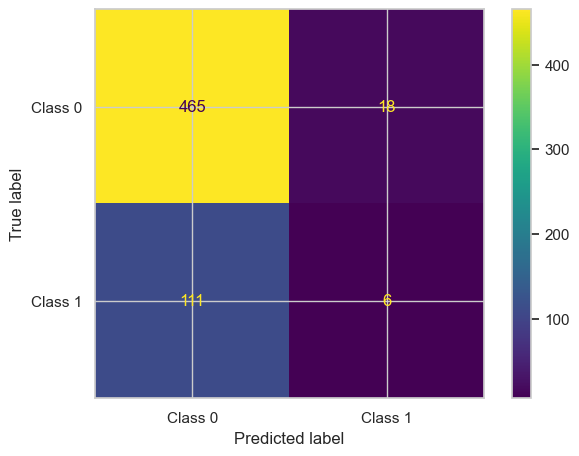

Classification Metrics:
   Metric    Class 0    Class 1 Accuracy Macro-Avg Weighted-Avg ROC-AUC-Score
Precision   0.807292   0.250000    0.785  0.528646      0.69862      0.580772
   Recall   0.962733   0.051282           0.507007        0.785              
 F1-Score   0.878187   0.085106           0.481647     0.723536              
  Support 483.000000 117.000000                                              

______________________FOLD 2______________________

19/19 [==============================] - 12s 600ms/step
ROC AUC Score: 0.6459450372493851


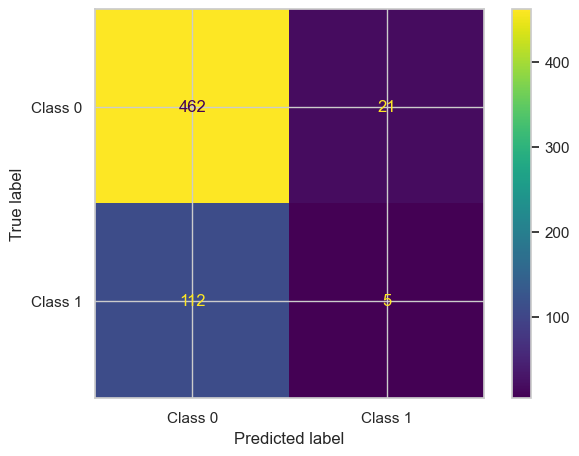

Classification Metrics:
   Metric    Class 0    Class 1  Accuracy Macro-Avg Weighted-Avg ROC-AUC-Score
Precision   0.804878   0.192308  0.778333  0.498593     0.685427      0.645945
   Recall   0.956522   0.042735            0.499628     0.778333              
 F1-Score   0.874172   0.069930            0.472051     0.717345              
  Support 483.000000 117.000000                                               

______________________FOLD 3______________________

19/19 [==============================] - 11s 600ms/step
ROC AUC Score: 0.637928898798464


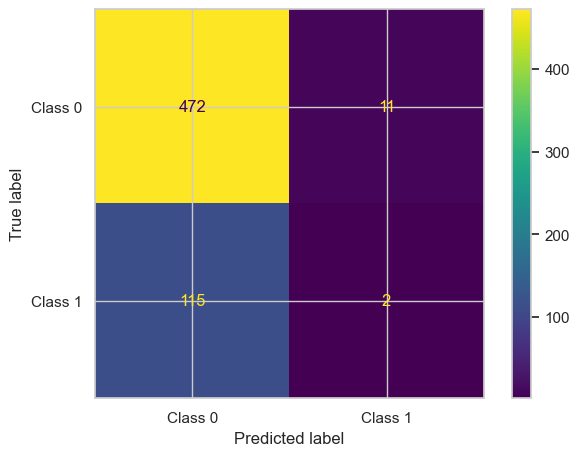

Classification Metrics:
   Metric    Class 0    Class 1 Accuracy Macro-Avg Weighted-Avg ROC-AUC-Score
Precision   0.804089   0.153846     0.79  0.478967     0.677291      0.637929
   Recall   0.977226   0.017094            0.49716         0.79              
 F1-Score   0.882243   0.030769           0.456506     0.716206              
  Support 483.000000 117.000000                                              

______________________FOLD 4______________________

19/19 [==============================] - 12s 606ms/step
ROC AUC Score: 0.6369733326255066


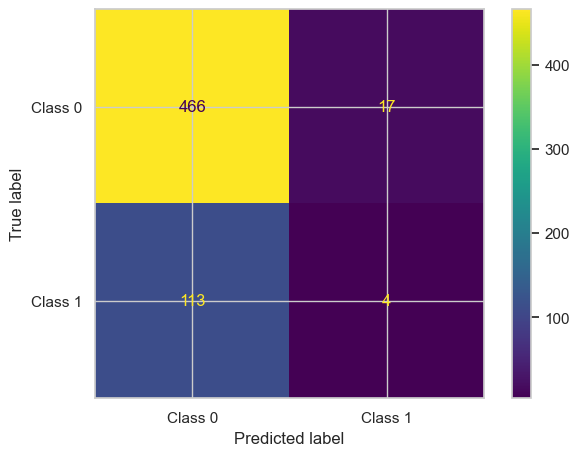

Classification Metrics:
   Metric    Class 0    Class 1  Accuracy Macro-Avg Weighted-Avg ROC-AUC-Score
Precision   0.804836   0.190476  0.783333  0.497656     0.685036      0.636973
   Recall   0.964803   0.034188            0.499496     0.783333              
 F1-Score   0.877589   0.057971             0.46778     0.717764              
  Support 483.000000 117.000000                                               

______________________FOLD 5______________________

19/19 [==============================] - 11s 600ms/step
ROC AUC Score: 0.5950522907044646


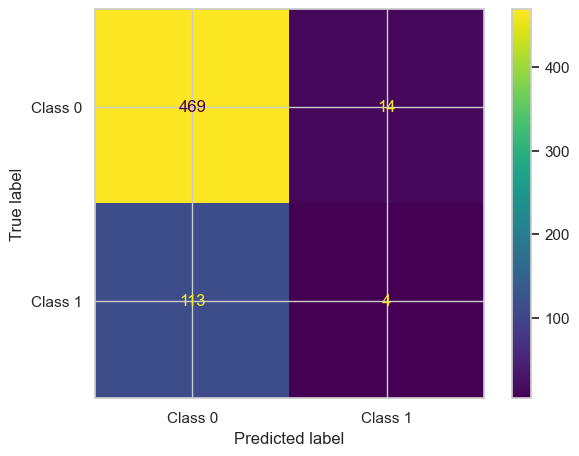

Classification Metrics:
   Metric    Class 0    Class 1  Accuracy Macro-Avg Weighted-Avg ROC-AUC-Score
Precision   0.805842   0.222222  0.788333  0.514032     0.692036      0.595052
   Recall   0.971014   0.034188            0.502601     0.788333              
 F1-Score   0.880751   0.059259            0.470005      0.72056              
  Support 483.000000 117.000000                                               


In [54]:
# Example usage with your test data
tfrec_test = tf.io.gfile.glob(['../../dataset/tf_records/test00.tfrec'])
X_test, y_test = get_dataset(tfrec_test, augment=True, shuffle=True, repeat=False, dim = 256)

model = build_model(dim=224)
for fold in range(CONFIG.FOLDS):
    print(f"\n______________________FOLD {fold + 1}______________________\n")
    model.load_weights('fold-%i.h5' % fold)
    test_evaluate(model, X_test, y_test)
    


______________________FOLD 1______________________

19/19 [==============================] - 15s 743ms/step
ROC AUC Score: 0.630673674151935


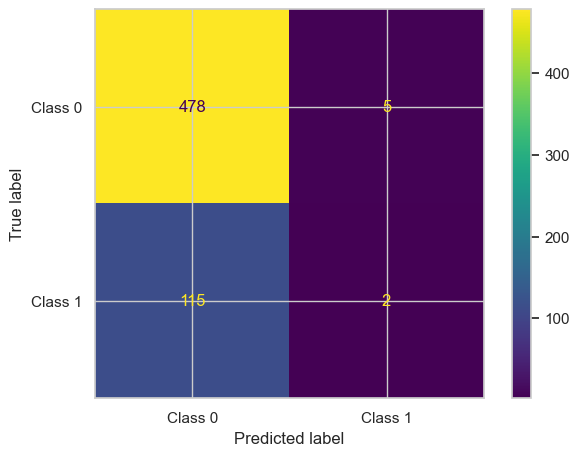

Classification Metrics:
   Metric    Class 0    Class 1 Accuracy Macro-Avg Weighted-Avg ROC-AUC-Score
Precision   0.806071   0.285714      0.8  0.545893     0.704601      0.630674
   Recall   0.989648   0.017094           0.503371          0.8              
 F1-Score   0.888476   0.032258           0.460367     0.721513              
  Support 483.000000 117.000000                                              

______________________FOLD 2______________________

19/19 [==============================] - 14s 705ms/step
ROC AUC Score: 0.590203677160199


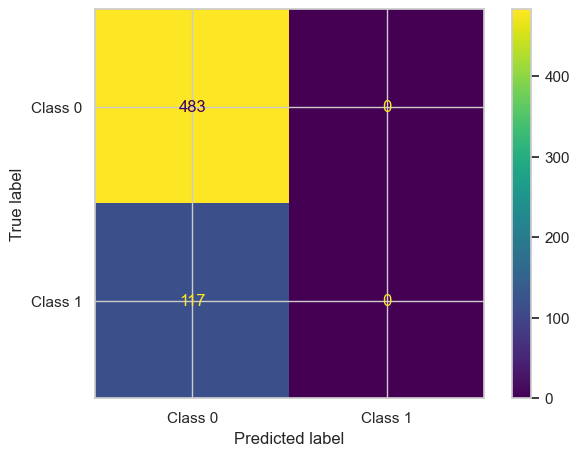

Classification Metrics:
   Metric    Class 0  Class 1 Accuracy Macro-Avg Weighted-Avg ROC-AUC-Score
Precision   0.805000      0.0    0.805    0.4025     0.648025      0.590204
   Recall   1.000000      0.0                0.5        0.805              
 F1-Score   0.891967      0.0           0.445983     0.718033              
  Support 483.000000    117.0                                              

______________________FOLD 3______________________

19/19 [==============================] - 13s 705ms/step
ROC AUC Score: 0.5796570579179274


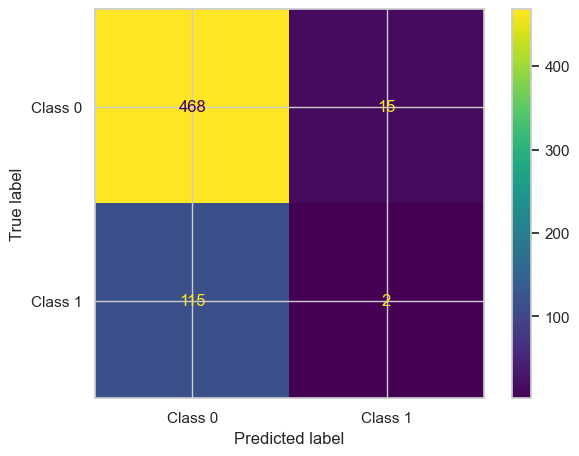

Classification Metrics:
   Metric    Class 0    Class 1  Accuracy Macro-Avg Weighted-Avg ROC-AUC-Score
Precision   0.802744   0.117647  0.783333  0.460196      0.66915      0.579657
   Recall   0.968944   0.017094            0.493019     0.783333              
 F1-Score   0.878049   0.029851             0.45395      0.71265              
  Support 483.000000 117.000000                                               

______________________FOLD 4______________________

19/19 [==============================] - 15s 760ms/step
ROC AUC Score: 0.6329387198952416


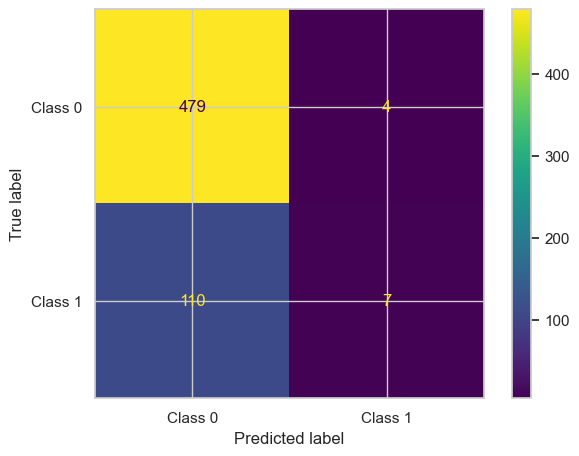

Classification Metrics:
   Metric    Class 0    Class 1 Accuracy Macro-Avg Weighted-Avg ROC-AUC-Score
Precision   0.813243   0.636364     0.81  0.724803     0.778751      0.632939
   Recall   0.991718   0.059829           0.525774         0.81              
 F1-Score   0.893657   0.109375           0.501516     0.740722              
  Support 483.000000 117.000000                                              

______________________FOLD 5______________________

19/19 [==============================] - 13s 671ms/step
ROC AUC Score: 0.5752508361204014


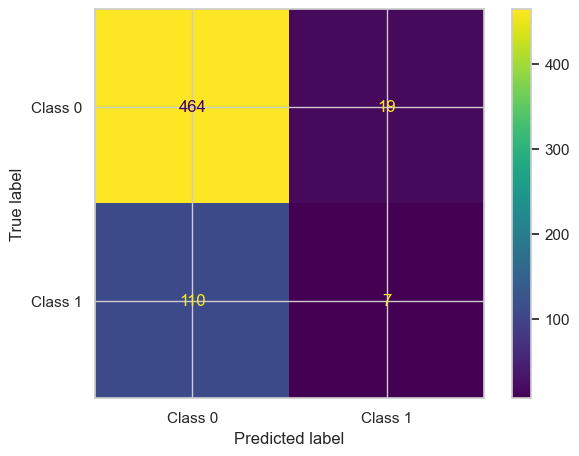

Classification Metrics:
   Metric    Class 0    Class 1 Accuracy Macro-Avg Weighted-Avg ROC-AUC-Score
Precision   0.808362   0.269231    0.785  0.538797     0.703232      0.575251
   Recall   0.960663   0.059829           0.510246        0.785              
 F1-Score   0.877956   0.097902           0.487929     0.725846              
  Support 483.000000 117.000000                                              


In [66]:
# Example usage with your test data
tfrec_test = tf.io.gfile.glob(['../../dataset/tf_records/test00.tfrec'])
X_test, y_test = get_dataset(tfrec_test, augment=True, shuffle=True, repeat=False, dim = 256)

model = build_model(dim=224)
for fold in range(CONFIG.FOLDS):
    print(f"\n______________________FOLD {fold + 1}______________________\n")
    model.load_weights('fold-%i.h5' % fold)
    test_evaluate(model, X_test, y_test)
    